# a2 - The cohort table and heatmap
learn-customer-retention-with-phoebe - by Phoebe Fu

The canonical pandas recipe: assign every customer to the month of their first order, count how
many are still ordering k months later, divide by month 0. This is the spine code of the whole
course. We run it on the retail segment first, then show what happens when wholesalers sneak in.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
retail = orders[orders["segment"] == "retail"].copy()
print(f"{len(orders):,} orders, {orders.customer_id.nunique():,} customers "
      f"({retail.customer_id.nunique():,} retail)")
orders.head()

18,137 orders, 4,030 customers (4,000 retail)


,customer_id,order_date,order_value,segment
0,C00020,2025-06-01,9.650,retail
1,C00337,2025-06-01,43.620,retail
2,C00529,2025-06-01,31.370,retail
3,C00720,2025-06-01,26.140,retail
4,C01000,2025-06-01,57.760,retail


## The canonical recipe (four lines that matter)

1. `order_month` = calendar month of each order
2. `cohort` = month of the customer's FIRST order, via a groupby-transform('min')
3. `period_number` = months elapsed between order month and cohort month
4. pivot on nunique customers, divide every row by its column 0

In [2]:
def cohort_table(df):
    df = df.copy()
    df["order_month"] = df["order_date"].dt.to_period("M")
    df["cohort"] = df.groupby("customer_id")["order_date"].transform("min").dt.to_period("M")
    df["period_number"] = (df["order_month"] - df["cohort"]).apply(lambda p: p.n)
    counts = df.pivot_table(index="cohort", columns="period_number",
                            values="customer_id", aggfunc="nunique")
    retention = counts.divide(counts.iloc[:, 0], axis=0)
    return counts, retention

counts_r, ret_r = cohort_table(retail)
cohort_sizes = counts_r.iloc[:, 0]
ret_r.round(3)

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort,,,,,,,,,,,,,,
2025-06,1.000,0.571,0.435,0.320,0.289,0.224,0.220,0.168,0.130,0.140,0.127,0.130,0.102,0.090
2025-07,1.000,0.571,0.469,0.380,0.340,0.302,0.243,0.208,0.216,0.178,0.162,0.140,0.148,NaN
2025-08,1.000,0.521,0.416,0.340,0.278,0.249,0.218,0.187,0.156,0.187,0.156,0.147,NaN,NaN
2025-09,1.000,0.604,0.473,0.384,0.317,0.284,0.262,0.183,0.162,0.155,0.152,NaN,NaN,NaN
2025-10,1.000,0.508,0.435,0.327,0.292,0.241,0.194,0.175,0.124,0.146,NaN,NaN,NaN,NaN
2025-11,1.000,0.617,0.413,0.356,0.310,0.271,0.213,0.222,0.198,NaN,NaN,NaN,NaN,NaN
2025-12,1.000,0.572,0.422,0.363,0.297,0.255,0.232,0.196,NaN,NaN,NaN,NaN,NaN,NaN
2026-01,1.000,0.560,0.468,0.342,0.305,0.258,0.230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02,1.000,0.554,0.397,0.320,0.271,0.234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The heatmap, done properly

Craft rules: single-hue sequential cmap (Oranges), vmin/vmax anchored so color is comparable
across charts, every cell annotated as a percent, and the lower-right triangle MASKED - those
cells are immature (the cohort has not lived that long yet), not zero. Blank means "not yet",
never "low".

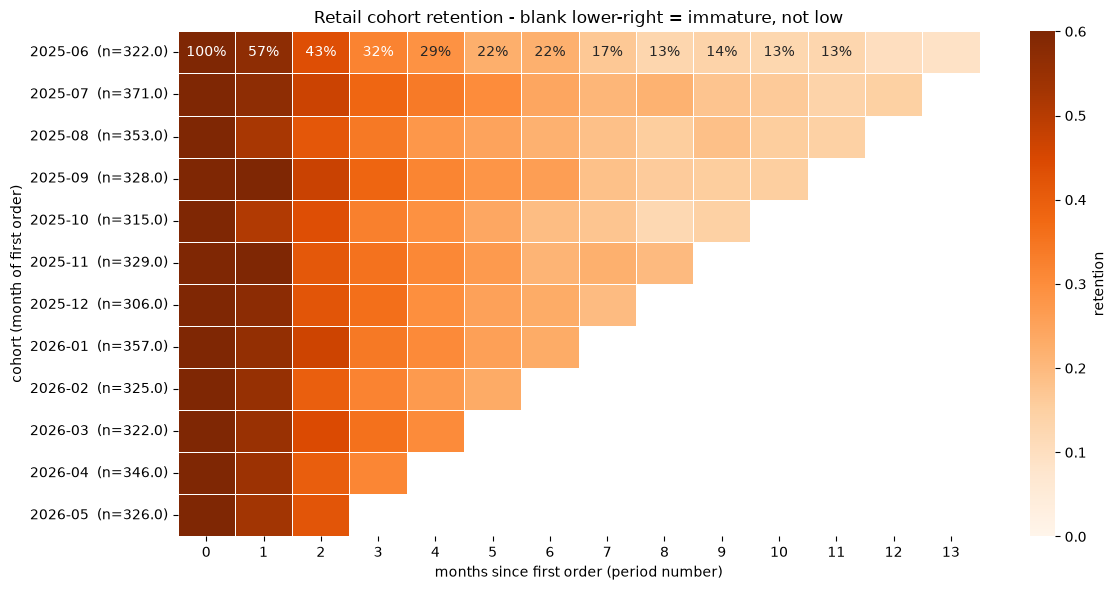

In [3]:
def plot_heatmap(ret, sizes, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    data = ret.copy()
    data.index = data.index.astype(str)
    sns.heatmap(data, annot=True, fmt=".0%", mask=data.isnull(),
                vmin=0, vmax=0.6, cmap="Oranges",
                linewidths=0.5, cbar_kws={"label": "retention"}, ax=ax)
    ax.set_yticklabels([f"{i}  (n={s:,})" for i, s in zip(data.index, sizes)], rotation=0)
    ax.set_xlabel("months since first order (period number)")
    ax.set_ylabel("cohort (month of first order)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(ret_r, cohort_sizes, "Retail cohort retention - blank lower-right = immature, not low")

## Second pass: leave the wholesalers in

Thirty wholesale accounts order every month and almost never churn. They are 0.7% of customers
but they never leave, so every long-lived cohort's tail gets a visible lift, and the early
cohorts (where wholesalers concentrate) look structurally better than they are. Segment before
you report.

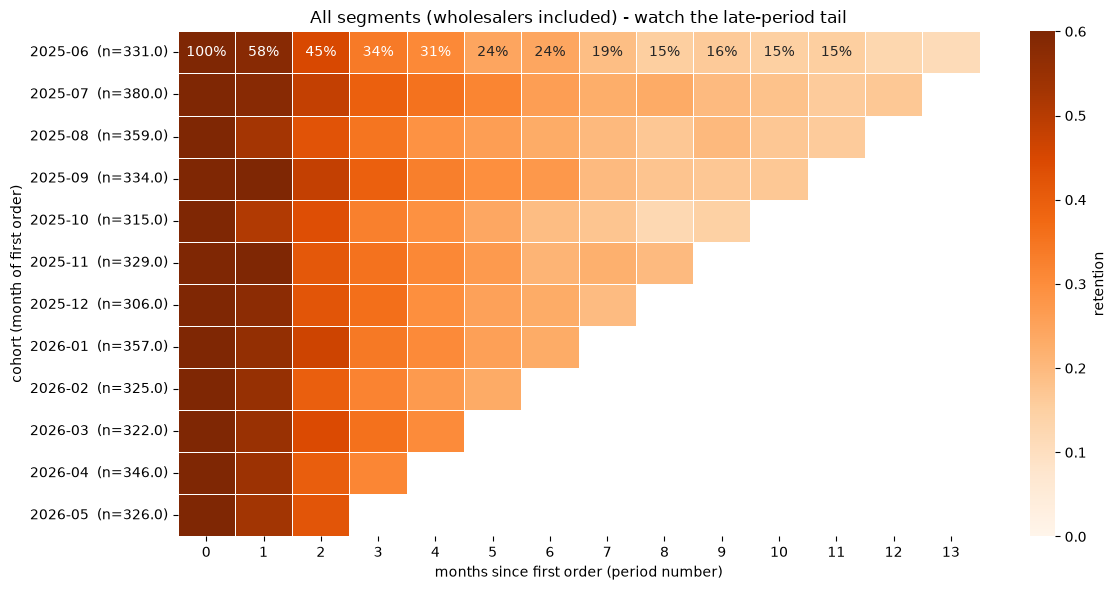

Cohort 2025-06, late periods:


,retail only,with wholesalers,lift (points)
period_number,,,
9,0.140,0.163,2.339
10,0.127,0.151,2.373
11,0.130,0.154,2.364
12,0.102,0.127,2.440
13,0.090,0.115,2.474


In [4]:
counts_all, ret_all = cohort_table(orders)
plot_heatmap(ret_all, counts_all.iloc[:, 0],
             "All segments (wholesalers included) - watch the late-period tail")

# Quantify the tail lift on the oldest cohort
oldest = ret_r.index[0]
tail_cols = [c for c in ret_r.columns if c >= 9 and not np.isnan(ret_r.loc[oldest, c])]
comp = pd.DataFrame({"retail only": ret_r.loc[oldest, tail_cols],
                     "with wholesalers": ret_all.loc[oldest, tail_cols]})
comp["lift (points)"] = (comp["with wholesalers"] - comp["retail only"]) * 100
print(f"Cohort {oldest}, late periods:")
comp.round(3)

## Same recipe on real-world mess: UCI Online Retail II

The course's second dataset is the UCI Online Retail II extract (1,067,371 rows, UK gift
retailer, 2009-2011): <https://archive.ics.uci.edu/dataset/502/online+retail+ii>

It is not bundled with this repo. Download it manually, then the exact same recipe applies after
cleaning: drop C-prefix invoices (cancellations, negative quantity), drop the ~135k rows with a
missing CustomerID, and expect a December-only first cohort. The code path below is left
commented out so this notebook always executes on the repo CSVs.

In [5]:
# Uncomment after downloading online_retail_II.xlsx next to the repo data/ folder:
#
# uci = pd.read_excel(ROOT / "data" / "online_retail_II.xlsx", sheet_name=None)
# uci = pd.concat(uci.values(), ignore_index=True)
# uci = uci[~uci["Invoice"].astype(str).str.startswith("C")]      # cancellations out
# uci = uci.dropna(subset=["Customer ID"])                         # guest checkouts out
# uci["order_value"] = uci["Quantity"] * uci["Price"]
# uci = uci.rename(columns={"Customer ID": "customer_id", "InvoiceDate": "order_date"})
# counts_uci, ret_uci = cohort_table(uci)
# plot_heatmap(ret_uci, counts_uci.iloc[:, 0], "Online Retail II cohorts")
print("Online Retail II path is documented above; all executed code runs on the repo CSVs.")

Online Retail II path is documented above; all executed code runs on the repo CSVs.
